# Оптимизация нейронных сетей. Метод обратного распространения ошибки (ноутбук)

> Узнаем как устроена оптимизация нейронных сетей. Оптимизация в `PyTorch`.

## План ноутбука

1. Высокоуровневое API для обучение нейросетей в `PyTorch`
2. Обучение первой нейросети в `PyTorch`

## Высокоуровневое API для обучение нейросетей в `PyTorch`

In [97]:
import torch
import torch.nn as nn

### Создание объекта нейросети

In [98]:
net = nn.Sequential(
    nn.Linear(700, 500),
    nn.ReLU(),
    nn.Linear(500, 200),
    nn.ReLU(),
    nn.Linear(200, 10)
)

In [99]:
net

Sequential(
  (0): Linear(in_features=700, out_features=500, bias=True)
  (1): ReLU()
  (2): Linear(in_features=500, out_features=200, bias=True)
  (3): ReLU()
  (4): Linear(in_features=200, out_features=10, bias=True)
)

In [100]:
net[1]

ReLU()

In [101]:
input = torch.randn((5, 700))

In [102]:
net(input)

tensor([[-0.0215,  0.0173, -0.1164, -0.0014, -0.0215,  0.0207, -0.0345,  0.1532,
         -0.0276,  0.0379],
        [-0.0612,  0.0303, -0.0097, -0.0422,  0.0083,  0.0065, -0.0140,  0.0992,
         -0.0338, -0.0333],
        [ 0.0065,  0.1687, -0.0572, -0.0207, -0.1088, -0.0578,  0.0351,  0.0680,
         -0.1483,  0.1754],
        [-0.0019,  0.0078, -0.0345, -0.0254,  0.0421, -0.0383,  0.0927,  0.1667,
         -0.2121,  0.1050],
        [ 0.0208,  0.0480, -0.0023, -0.0338, -0.0544,  0.0179, -0.0467, -0.0022,
         -0.1410,  0.0036]], grad_fn=<AddmmBackward0>)

In [103]:
net(input).shape

torch.Size([5, 10])

In [104]:
from collections import OrderedDict

net = nn.Sequential(
    OrderedDict(
        [
            ('linear1', nn.Linear(700, 500)),
            ('relu1', nn.ReLU()),
            ('linear2', nn.Linear(500, 200)),
            ('relu2', nn.ReLU()),
            ('linear3', nn.Linear(200, 10))
        ]
    )
)

In [105]:
net.linear1.weight

Parameter containing:
tensor([[-0.0131,  0.0241, -0.0304,  ..., -0.0354, -0.0353,  0.0252],
        [ 0.0299,  0.0214,  0.0197,  ...,  0.0174, -0.0304, -0.0010],
        [-0.0353,  0.0188,  0.0167,  ...,  0.0337, -0.0223, -0.0137],
        ...,
        [ 0.0277,  0.0101, -0.0047,  ...,  0.0301,  0.0270,  0.0354],
        [-0.0316, -0.0231,  0.0004,  ..., -0.0271,  0.0200, -0.0240],
        [ 0.0172, -0.0288,  0.0040,  ...,  0.0122,  0.0031, -0.0065]],
       requires_grad=True)

In [106]:
net

Sequential(
  (linear1): Linear(in_features=700, out_features=500, bias=True)
  (relu1): ReLU()
  (linear2): Linear(in_features=500, out_features=200, bias=True)
  (relu2): ReLU()
  (linear3): Linear(in_features=200, out_features=10, bias=True)
)

In [107]:
input_tensor = torch.rand(10, 700)

net(input_tensor).shape

torch.Size([10, 10])

In [108]:
class CustomTaskNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(700, 500)
        self.linear2 = nn.Linear(500, 200)
        self.linear3 = nn.Linear(200, 10)

        self.activation1 = nn.ReLU()
        self.activation2 = nn.Sigmoid()

    def forward(self, x):
        output = self.activation1(self.linear1(x))
        output = self.activation2(self.linear2(output))
        output = self.linear3(output)

        return output

In [118]:
class CustomTaskNetwork_new(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(700, 500)
        self.linear2 = nn.Linear(500, 200)
        self.linear3 = nn.Linear(200, 10)
        self.linear4 = nn.Linear(10, 10)

        self.activation1 = nn.ReLU()
        self.activation2 = nn.Sigmoid()

    def forward(self, x):
        output = self.activation1(self.linear1(x))
        output = self.activation2(self.linear2(output))
        output = self.linear3(output)
        output = self.linear4(output)

        return output

In [119]:
net_new = CustomTaskNetwork_new()
net_new = net_new.to("cuda:2")

In [109]:
net = CustomTaskNetwork()

net(input_tensor).shape

torch.Size([10, 10])

In [110]:
net = net.to("cuda:2")

In [111]:
net

CustomTaskNetwork(
  (linear1): Linear(in_features=700, out_features=500, bias=True)
  (linear2): Linear(in_features=500, out_features=200, bias=True)
  (linear3): Linear(in_features=200, out_features=10, bias=True)
  (activation1): ReLU()
  (activation2): Sigmoid()
)

In [15]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(net)

452710

In [112]:
700 * 500 + 500 + 500 * 200 + 200 + 200 * 10 + 10

452710

In [113]:
net.train()

net.eval()

net.requires_grad_(False)

CustomTaskNetwork(
  (linear1): Linear(in_features=700, out_features=500, bias=True)
  (linear2): Linear(in_features=500, out_features=200, bias=True)
  (linear3): Linear(in_features=200, out_features=10, bias=True)
  (activation1): ReLU()
  (activation2): Sigmoid()
)

In [114]:
n = next(net.parameters())
n

Parameter containing:
tensor([[-0.0087, -0.0313,  0.0115,  ...,  0.0135,  0.0309,  0.0223],
        [-0.0053,  0.0252,  0.0100,  ...,  0.0184, -0.0294, -0.0116],
        [-0.0278,  0.0095, -0.0102,  ...,  0.0185,  0.0202, -0.0226],
        ...,
        [-0.0018,  0.0358, -0.0014,  ..., -0.0283,  0.0310,  0.0152],
        [-0.0188, -0.0247,  0.0043,  ...,  0.0371, -0.0024,  0.0341],
        [-0.0092, -0.0327,  0.0370,  ...,  0.0260,  0.0109, -0.0024]],
       device='cuda:2')

In [115]:
type(n)

torch.nn.parameter.Parameter

In [20]:
torch.save(net.state_dict(), "weights.pth")

In [117]:
net

CustomTaskNetwork(
  (linear1): Linear(in_features=700, out_features=500, bias=True)
  (linear2): Linear(in_features=500, out_features=200, bias=True)
  (linear3): Linear(in_features=200, out_features=10, bias=True)
  (activation1): ReLU()
  (activation2): Sigmoid()
)

In [116]:
weights = torch.load("weights.pth", map_location="cpu")
net.load_state_dict(weights)
net.state_dict()

OrderedDict([('linear1.weight',
              tensor([[ 0.0026,  0.0045, -0.0274,  ..., -0.0312, -0.0170,  0.0265],
                      [-0.0108, -0.0262, -0.0069,  ...,  0.0295,  0.0153, -0.0264],
                      [-0.0196, -0.0165, -0.0297,  ..., -0.0278, -0.0375, -0.0092],
                      ...,
                      [ 0.0352,  0.0131, -0.0133,  ...,  0.0012, -0.0113,  0.0200],
                      [ 0.0221, -0.0187, -0.0269,  ...,  0.0187, -0.0360, -0.0266],
                      [-0.0048, -0.0202, -0.0173,  ..., -0.0270, -0.0196, -0.0104]],
                     device='cuda:2')),
             ('linear1.bias',
              tensor([-3.4124e-02, -2.7440e-02,  4.7279e-03,  3.2241e-02, -2.1372e-02,
                       1.0692e-02,  6.4306e-03, -1.7771e-02, -2.3823e-02,  3.7453e-02,
                       3.4873e-02, -4.3138e-03,  1.5905e-02, -2.2770e-02,  3.7321e-02,
                       2.8725e-02, -3.5648e-02, -6.6169e-03,  2.2518e-02,  3.1964e-02,
                  

In [120]:
weights = torch.load("weights.pth", map_location="cpu")
net_new.load_state_dict(weights)
net_new.state_dict()

RuntimeError: Error(s) in loading state_dict for CustomTaskNetwork_new:
	Missing key(s) in state_dict: "linear4.weight", "linear4.bias". 

Если мы хотим проинициализировать сетку какими-то весами из словаря, то важно чтобы названия и размеры параметров в передаваемом словаре совпадали с названиями и размерами параметров сетки

In [124]:
net.load_state_dict({'linear5.weight': torch.rand((1, 2, 3))}, strict=False)

_IncompatibleKeys(missing_keys=['linear1.weight', 'linear1.bias', 'linear2.weight', 'linear2.bias', 'linear3.weight', 'linear3.bias'], unexpected_keys=['linear5.weight'])

In [125]:
net.linear1.weight.device

device(type='cuda', index=2)

### Оптимизаторы

In [126]:
from torch import optim

In [127]:
optim.SGD, optim.Adam

(torch.optim.sgd.SGD, torch.optim.adam.Adam)

In [128]:
optimizer = optim.Adam(net.parameters(), lr=0.0001)

In [129]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)

In [130]:
optimizer = optim.SGD(
    [
        {'params': net.linear1.parameters()},
        {'params': net.linear2.parameters(), 'lr': 1e-3}
    ],
    lr=1e-2,
    momentum=0.9
)

In [131]:
optimizer.step()

In [132]:
optimizer.zero_grad()

In [32]:
checkpoint = {
    'epoch': 23,
    'model': net,
    'optimizer': optimizer
    }
torch.save(checkpoint, 'checkpoint.pth')

In [133]:
checkpoint = torch.load('checkpoint.pth', weights_only=False)
epoch = checkpoint['epoch']
model = checkpoint['model']
optimizer = checkpoint['optimizer']

In [134]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0

Parameter Group 1
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)

### Функции потерь

In [35]:
nn.L1Loss, nn.MSELoss, nn.CrossEntropyLoss

(torch.nn.modules.loss.L1Loss,
 torch.nn.modules.loss.MSELoss,
 torch.nn.modules.loss.CrossEntropyLoss)

In [135]:
loss = nn.MSELoss()

In [136]:
net = nn.Sequential(
    nn.Linear(700, 500),
    nn.ReLU(),
    nn.Linear(500, 200),
    nn.ReLU(),
    nn.Linear(200, 10)
)

In [137]:
input_tensor = torch.randn(10, 700, device="cuda")
net = net.to("cuda")
input = net(input_tensor)
target = torch.randn(10, 10, device="cuda")

output = loss(input, target)

print(output)

output.backward()

tensor(0.7522, device='cuda:0', grad_fn=<MseLossBackward0>)


In [138]:
net[0].weight.grad

tensor([[-1.6905e-04,  3.2298e-04,  4.2738e-05,  ...,  5.5580e-04,
         -5.1647e-04,  1.1702e-03],
        [-2.5690e-04,  1.7029e-04,  6.7545e-05,  ..., -1.2934e-04,
          2.1691e-04, -6.3203e-04],
        [-1.5568e-04, -4.0320e-04, -8.5580e-05,  ...,  1.6857e-04,
         -4.6732e-04,  1.8376e-03],
        ...,
        [ 6.5161e-05,  4.1166e-04, -5.2727e-05,  ...,  6.5133e-05,
          3.6372e-04, -6.4825e-04],
        [ 3.4934e-04,  3.6400e-05,  8.7958e-04,  ..., -1.4714e-03,
          7.5861e-04, -1.6137e-03],
        [-2.5725e-04,  1.7078e-04, -8.1954e-06,  ..., -3.7558e-04,
         -6.3086e-04, -1.0770e-03]], device='cuda:0')

### Датасеты и даталоадеры

#### Датасет

In [139]:
from torch.utils.data import Dataset
from torch.utils.data import TensorDataset

In [140]:
n_features = 2
n_objects = 300

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [141]:
w_true = torch.randn(n_features)

X = (torch.rand(n_objects, n_features) - 0.5) * 10
X *= (torch.arange(n_features) * 2 + 1)
Y = (X @ w_true + torch.randn(n_objects)).unsqueeze(1)

In [142]:
X.shape, Y.shape

(torch.Size([300, 2]), torch.Size([300, 1]))

In [143]:
dataset = TensorDataset(X, Y)

In [144]:
dataset[7]

(tensor([-2.3342,  3.8235]), tensor([0.3727]))

In [145]:
X[7], Y[7]

(tensor([-2.3342,  3.8235]), tensor([0.3727]))

In [149]:
# надо отнаследоваться от Dataset и определить методы __init__, __len__ и __getitem__

class CustomDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, item):
        return self.X[item], self.Y[item], "123"

In [150]:
dataset = CustomDataset(X, Y)

In [151]:
dataset[7]

(tensor([-2.3342,  3.8235]), tensor([0.3727]), '123')

In [152]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Compose, Lambda

dataset = MNIST(root="./data", transform=Compose([ToTensor(), Lambda(lambda x: torch.flatten(x))]), download=True)

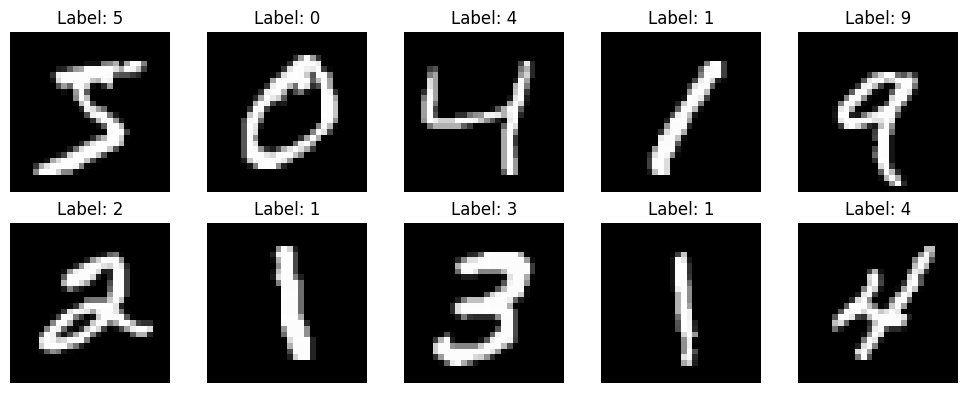

In [91]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, (image, label) in zip(axes.flat, [dataset[i] for i in range(10)]):
    ax.imshow(image.reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [153]:
dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [154]:
dataset[0][0].shape

torch.Size([784])

In [58]:
28 * 28

784

#### Даталоадер

[тык](https://docs.pytorch.org/docs/stable/data.html#memory-pinning)

In [157]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=10)
next(iter(loader))

[tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])]

In [158]:
loader = DataLoader(dataset, batch_size=2, shuffle=True)
next(iter(loader))

[tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([4, 5])]

collate

In [159]:
class CustomDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, item):
        return {"input": self.X[item], "target": self.Y[item], "meta_info": {"path": "hahaha", "link": "eheheh"}}

In [160]:
dataset = CustomDataset(X, Y)
dataset[0]

{'input': tensor([-1.0955,  3.0269]),
 'target': tensor([0.4938]),
 'meta_info': {'path': 'hahaha', 'link': 'eheheh'}}

In [161]:
loader = DataLoader(dataset, batch_size=2)
next(iter(loader))

{'input': tensor([[-1.0955,  3.0269],
         [-2.4343,  8.8092]]),
 'target': tensor([[0.4938],
         [0.6791]]),
 'meta_info': {'path': ['hahaha', 'hahaha'], 'link': ['eheheh', 'eheheh']}}

In [162]:
def collate_fn(batch):
    """
    batch: list of outputs getitem
    """
    input = torch.zeros(len(batch), *batch[0]["input"].shape)
    target = torch.zeros(len(batch), 1)

    for i in range(len(batch)):
        input[i] = batch[i]["input"]
        target[i] = batch[i]["target"]

    # other stuff with meta info ...
    
    return {"input": input, "target": target}

In [163]:
loader = DataLoader(dataset, batch_size=2, collate_fn=collate_fn)
next(iter(loader))

{'input': tensor([[-1.0955,  3.0269],
         [-2.4343,  8.8092]]),
 'target': tensor([[0.4938],
         [0.6791]])}

### Общая структура обучения модели

Модель

In [164]:
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, hidden_size=100):
        super().__init__()

        self.linear1 = nn.Linear(784, hidden_size)
        self.linear2 = nn.Linear(hidden_size, 10)


    def forward(self, x):
        # (batch_size, 1, 28, 28)
        x = torch.flatten(x, start_dim=1)
        # (batch_size, 784)
        x = self.linear1(x)
        x = F.relu(x)
        x = self.linear2(x)
        return x

model = MLP().to("cuda")

Оптимизатор

In [165]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

Данные

In [166]:
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

train_set = MNIST('./MNIST', transform=ToTensor(), train=True, download=True)
val_set = MNIST('./MNIST', transform=ToTensor(), train=False, download=True)

In [167]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, drop_last=True)

In [168]:
count_parameters(model)

79510

In [169]:
def test(model, loader):
    model.eval()

    correct, total = 0, 0

    for batch in loader:
        images, labels = batch[0], batch[1]
        images = images.to('cuda')
        # batch size * 1
        labels = labels.to('cuda')

        with torch.no_grad():
            # batch_size * 10
            out = model(images)
        # shape pred = batch_size * 1
        pred = torch.argmax(out, dim=1)

        total += len(pred)
        correct += (pred == labels).cpu().numpy().sum()

    return correct / total

In [170]:
def train(model, train_loader, val_loader, optimizer, epochs=10):
    train_acc, val_acc = [], []
    model.train()

    for epoch in range(epochs):

        correct, total = 0, 0

        for images, labels in train_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')

            optimizer.zero_grad()
            out = model(images)
            loss = F.cross_entropy(out, labels)
            loss.backward()
            optimizer.step()

            pred = torch.argmax(out, dim=1)

            total += len(pred)
            correct += (pred == labels).detach().cpu().numpy().sum()

        train_acc.append(correct / total)
        val_acc.append(test(model, val_loader))
        torch.save(model.state_dict(), f"my_model_{epoch}.pth")

        print(f"Epoch: {epoch}")
        print(f"train accuracy: {train_acc[-1]}")
        print(f"val accuracy: {val_acc[-1]}")

    return train_acc, val_acc

In [171]:
test(model, val_loader)

0.13631810897435898

In [172]:
train_acc, val_acc = train(model, train_loader, val_loader, optimizer, epochs=5)

Epoch: 0
train accuracy: 0.9095385950854701
val accuracy: 0.9515224358974359
Epoch: 1
train accuracy: 0.9649272168803419
val accuracy: 0.9658453525641025
Epoch: 2
train accuracy: 0.9746427617521367
val accuracy: 0.967948717948718
Epoch: 3
train accuracy: 0.9792835202991453
val accuracy: 0.9702524038461539
Epoch: 4
train accuracy: 0.9834234775641025
val accuracy: 0.9746594551282052


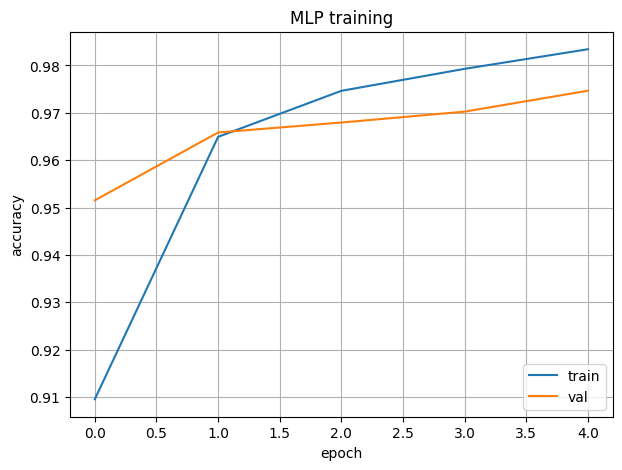

In [174]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(np.arange(5), train_acc, label='train')
plt.plot(np.arange(5), val_acc, label='val')

plt.grid()
plt.legend(loc='lower right')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("MLP training")
plt.show()

Сохранение обученной модели

In [175]:
torch.save(model.state_dict(), "my_model.pth")

Применение обученной модели для получения предсказания

In [176]:
model.eval()

it = iter(val_loader)
elem = next(it)

with torch.no_grad():
    print(torch.argmax(model(elem[0][52].to("cuda"))))

tensor(5, device='cuda:0')


In [177]:
dataset = MNIST("./MNIST", train=False)
dataset[52][0]

и правда